**_#1.跳跃游戏_**

贪心写法

In [ ]:
class Solution(object):
    def canJump(self, nums):
        """
        :type nums: List[int]
        :rtype: bool
        """
        t = len(nums) - 1

        for i in range(len(nums)-2,-1,-1):
            if i + nums[i] >= t:
                t = i#对于这一种写法而言，会不断的把希望到达的点前移，如果更前面的点连t这个比较前面的点都无法到达的话，那就更不用讨论能否到达后面的点了

        return t == 0

动态规划写法

In [ ]:
class Solution(object):
    def canJump(self, nums):
        """
        :type nums: List[int]
        :rtype: bool
        """
        n = len(nums)
        dp = [False] * n
        dp[0] = True

        for i in range(n-1):
            for j in range(1,nums[i]+1):
                if i + j < n and dp[i] == True:
                    dp[i+j] = True

        return dp[n-1]

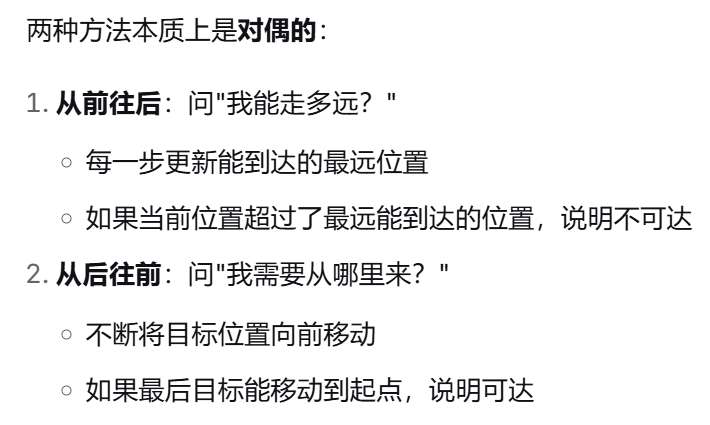

跳跃游戏II

这个题的思路在于覆盖区间的确定，最开始时覆盖区间为0，因此肯定需要一次跳跃使其跳到下一个目前尚不知道的覆盖区域当中去，在遍历下一个覆盖区域的元素时（对于这个区域内的元素，只需走一次就能走到）记录目前能走到的最远索引值是多少，当走到这个区域的最后一个值的时候，就需要扩大覆盖区域的大小，又因为后面的元素走一步肯定是走不到的，所以步数需要加一

**_"在每一跳的范围内，找到下一跳能跳得最远的点作为落脚点"_**

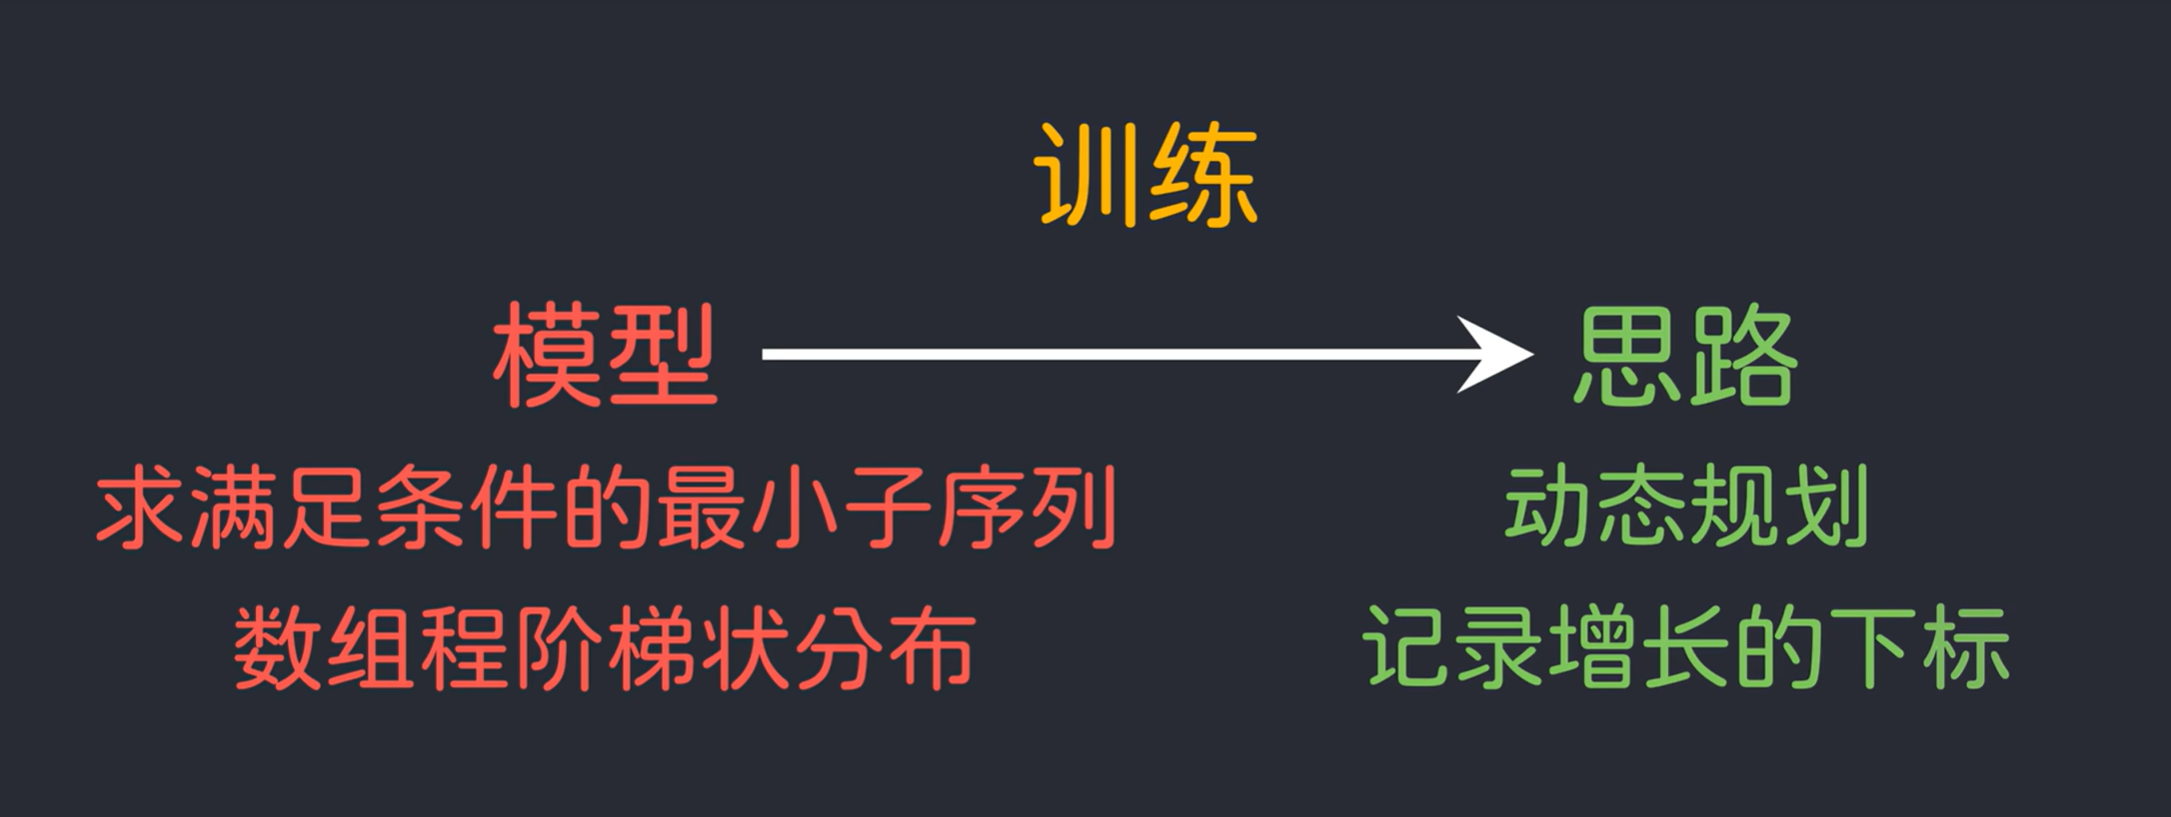

条件:从头走到尾

最小子序列:走过的步数最少，涉及到的元素的个数最少，也即最小子序列

In [ ]:
class Solution(object):#只能记录从起点到终点的最少步数，中间的无法记录
    def jump(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        step = curr_end = farset_end = 0

        for i in range(len(nums) - 1):#不会遍历到最后一个元素，从而避免了一次i == farest_end的判断
            curr_end = max(curr_end,i + nums[i])

            if i == farset_end:
                step += 1
                farset_end = curr_end #在进行这一步操作的时候，其实就是确定了应该以当前覆盖区域的哪一个元素为新的起点

        return step

In [1]:
class Solution(object):
    def jump(self, nums):
        """
        :type nums: List[int]
        :rtype: int
        """
        #dp写法
        n = len(nums)
        dp = [float('inf')] * n #不用设置判断节点是否可达的列表，因为距离列表的值初始化为无穷大，如果当前节点无法到达的话，那么dp[i+j],dp[i]+1的最小值还是无穷大，索引上的值为无穷大就意味着这个点不可达
        dp[0] = 0

        for i in range(n-1):
            for j in range(1,nums[i]+1):
                if i + j < n:
                    dp[i+j] = min(dp[i+j],dp[i]+1)#这个问题也可以看成一个爬台阶问题，最开始时我们位于台阶0，需要跳一步走到台阶1，而当我们遇到台阶一的最后一个值的时候，我们又需要再跳一步爬到台阶2，因此我们只需要记录每个台阶的最后一个数的索引即可，当遍历到这索引的时候就必须跳一步以到达后面的位置

                    #对于同一个元素，先被遍历到的步数一定比后被遍历到的步数少，简单来说就是一步就能做到的事情就不要两步
        return dp[n-1]